In [1]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [4]:
def retrieve_stock_data(stock_symbol, start_date, end_date ):
  data = yf.download(stock_symbol, start = start_date, end = end_date)
  return data


In [5]:
stock_data = retrieve_stock_data("AAPL", "2020-01-01", "2023-01-01")

[*********************100%***********************]  1 of 1 completed


In [6]:
 stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.796013,72.856606,71.54538,71.799866,135480400
2020-01-03,72.088303,72.851769,71.86290,72.020439,146322800
2020-01-06,72.662720,72.701500,70.95401,71.206077,118387200
2020-01-07,72.320969,72.929314,72.10041,72.672402,108872000
2020-01-08,73.484344,73.787308,72.02285,72.022850,132079200


Text(0, 0.5, 'Closing Price')

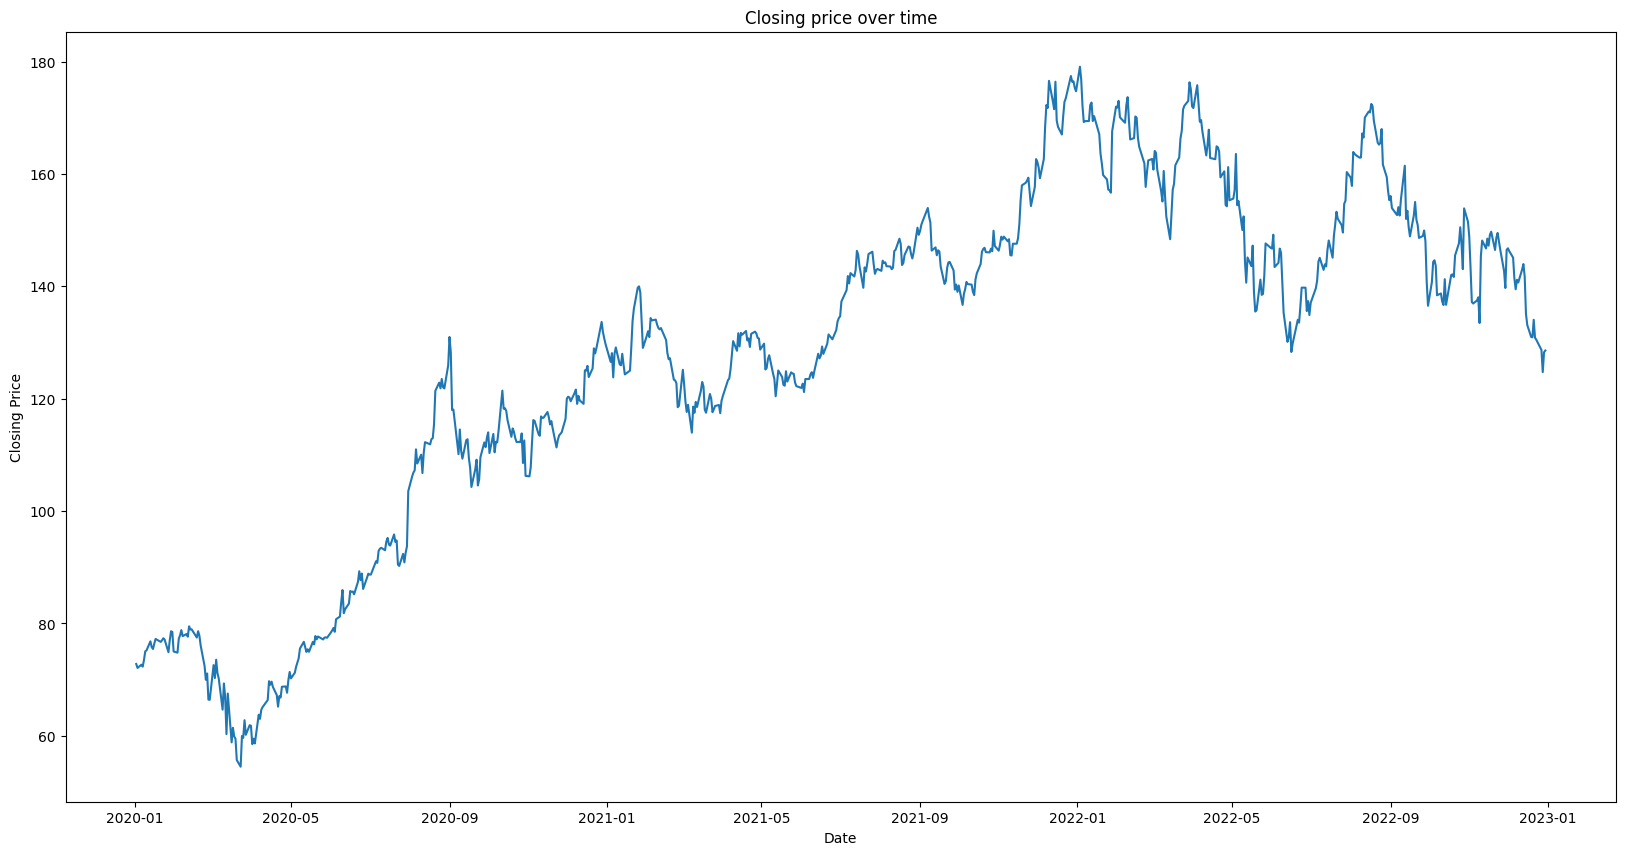

In [8]:
plt.figure(figsize=(20,10))
plt.plot(stock_data["Close"])
plt.title("Closing price over time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

In [10]:
 train_size = int(len(stock_data)*0.8)
 train_data, test_data = stock_data[:train_size], stock_data[train_size:]

In [11]:
print(len(train_data))
print(len(test_data))

604
152


In [12]:
train_data = train_data["Close"]
test_data = test_data["Close"]

In [20]:
def find_best_arima_order(data, p_values, d_values, q_values):
   best_score, best_cfg = float("inf"), None
   for p in p_values:
    for d in d_values:
      for q in q_values:
        try:
          model = ARIMA(data, order = (p,d,q))
          model_fit = model.fit()
          mse = mean_squared_error(data, model_fit.fittedvalues)
          if mse < best_score:
            best_score, best_cfg = mse, (p,d,q)
        except:
          continue
    return best_cfg

In [21]:
p_values = range(0,3)
d_values = range(0,3)
q_values = range(0,3)

In [22]:
best_cfg = find_best_arima_order(train_data, p_values, d_values, q_values)
print("Best ARIMA parametes: ARIMA{}". format(best_cfg))

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Best ARIMA parametes: ARIMA(0, 1, 2)


In [23]:
model = ARIMA(train_data, order = best_cfg)
model_fit = model.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [25]:
forecasted_values = model_fit.forecast(steps = len(test_data))

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [26]:
mse = mean_squared_error(test_data, forecasted_values)
print("Mean Squared Error(MSE): {:.2f}".format(mse))

Mean Squared Error(MSE): 174.28


In [27]:
forecasted_values = model_fit.forecast(steps = 180)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [28]:
forecast_dates = pd.date_range(start = test_data.index[-1], periods = 180, freq = "D")

In [29]:
forecast_df = pd.DataFrame({"Date": forecast_dates, "Forecasted": forecasted_values})

In [30]:
forecast_df.head()

,Date,Forecasted
604,2022-12-30,138.651247
605,2022-12-31,138.654091
606,2023-01-01,138.654091
607,2023-01-02,138.654091
608,2023-01-03,138.654091


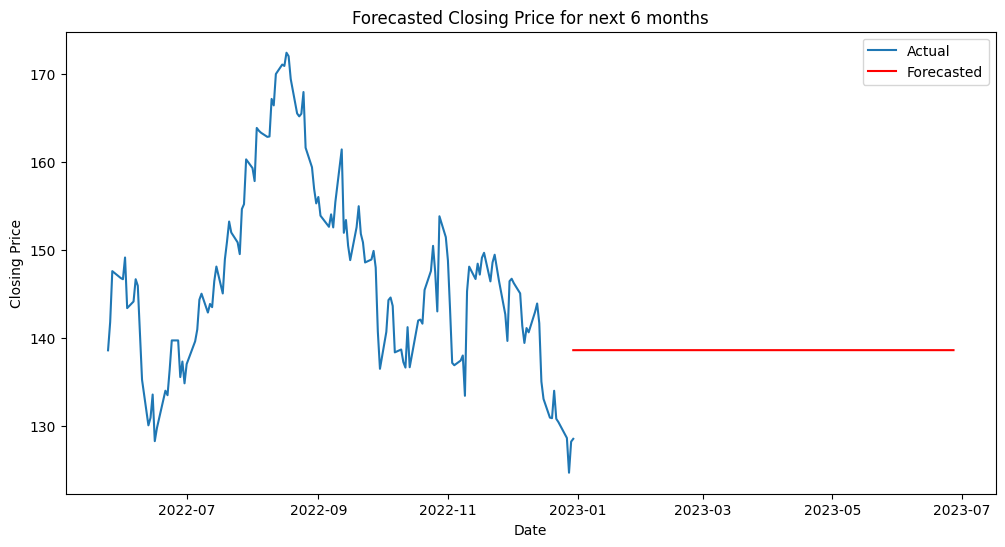

In [31]:
plt.figure(figsize=(12,6))
plt.plot(test_data.index, test_data, label = "Actual")
plt.plot(forecast_df["Date"], forecast_df["Forecasted"], label = "Forecasted", color = "r")
plt.title("Forecasted Closing Price for next 6 months")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()